# Analysis of the synoptic flow regimes around Taiwan using TaiESM1# 
分析TaiEMS1的綜觀流場需要完成以下幾件事情:
1. 時間挑選在historical跟ssp585的情境下，挑選2年(2010-2011,2099-2100)把10月到4月的資料擷取出來
2. 篩選空間範圍為東亞的區域:100E-150E,10N-50N
3. 將使用每天的地面氣壓場、降水、1000 hPa風場
4. 選取石垣島周邊一定範圍計算風向的變異程度作為指標
5. 將台灣含括在內的一定範圍計算降水網格數量的比例
6. 畫出地面天氣圖並上述兩指標標示在圖上後，診斷該日是否符合local circulation dimunated days(延伸議題:此一天數變化與ENSO之類的interannual訊號之關聯?)


In [1]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import pandas as pd
from glob import glob
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
%matplotlib inline

ishigaki={'lat':24.33,'lon':124.16}
subplot_kws=dict(projection=ccrs.PlateCarree(central_longitude=180))

In [2]:
dataDir='/data/mileshsieh/CMIP6'
m='TaiESM1'
sce='ssp585'

template='%s/%s/%s/atmos/day/r1i1p1f1/%s_day_%s_%s_r1i1p1f1_gn_%04d0101-*.nc'
varList=['psl','ua','va','pr']

In [3]:
[min_lon, max_lon, min_lat, max_lat]=[100.,150.,10.,50.]
#yrDict={'ssp585':[2075,'2078-04-11','2078-04-16']} #[start yr of files,stat_start_date,stat_end_date]
#yrDict={'ssp585':[2085,'2092-04-13','2092-04-17']} #[start yr of files,stat_start_date,stat_end_date]
yrDict={'ssp585':[2085,'2092-03-25','2092-03-27']} #[start yr of files,stat_start_date,stat_end_date]
#yrDict={'ssp585':[2035,'2037-10-15','2037-10-17']} #[start yr of files,stat_start_date,stat_end_date]
p_selected=1000

yr_start=yrDict[sce][0]
#open multiple files
fList=[glob(template%(dataDir,m,sce,var,m,sce,yr_start))[0] for var in varList]
#print(len(fList),fList)
#open multiple files
ds=xr.open_mfdataset(fList).sel(lat=slice(min_lat,max_lat),lon=slice(min_lon,max_lon),
                                        time=slice(yrDict[sce][1], yrDict[sce][2]),plev=p_selected*100)
ds

<xarray.Dataset>
Dimensions:    (time: 3, bnds: 2, lat: 42, lon: 41)
Coordinates:
  * time       (time) object 2092-03-25 12:00:00 ... 2092-03-27 12:00:00
  * lat        (lat) float64 10.84 11.78 12.72 13.66 ... 46.65 47.59 48.53 49.48
  * lon        (lon) float64 100.0 101.2 102.5 103.8 ... 146.2 147.5 148.8 150.0
    plev       float64 1e+05
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object dask.array<chunksize=(3, 2), meta=np.ndarray>
    lat_bnds   (lat, bnds) float64 dask.array<chunksize=(42, 2), meta=np.ndarray>
    lon_bnds   (lon, bnds) float64 dask.array<chunksize=(41, 2), meta=np.ndarray>
    pr         (time, lat, lon) float32 dask.array<chunksize=(3, 42, 41), meta=np.ndarray>
    psl        (time, lat, lon) float32 dask.array<chunksize=(3, 42, 41), meta=np.ndarray>
    ua         (time, lat, lon) float32 dask.array<chunksize=(3, 42, 41), meta=np.ndarray>
    va         (time, lat, lon) float32 dask.array<chunksize=(3, 42, 41), meta=np.ndarray>
Attributes: (12/50)
    Conventions:               CF-1.7 CMIP-6.2
    activity_id:               ScenarioMIP
    branch_method:             Hybrid-restart from year 2015-01-01 of historical
    branch_time:               0.0
    branch_time_in_child:      0.0
    branch_time_in_parent:     60225.0
    ...                        ...
    title:                     TaiESM1 output prepared for CMIP6
    variable_id:               pr
    variant_label:             r1i1p1f1
    license:                   CMIP6 model data produced by NCC is licensed u...
    cmor_version:              3.5.0
    tracking_id:               hdl:21.14100/8f648d72-0fc3-4f6e-9794-14c554a451f7

2092-03-25
2092-03-26
2092-03-27


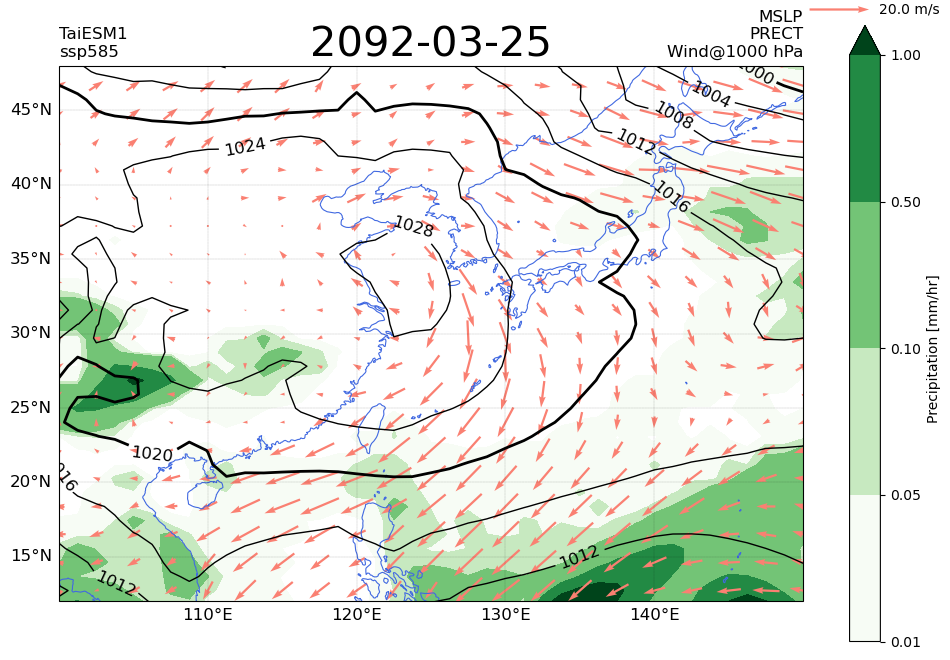

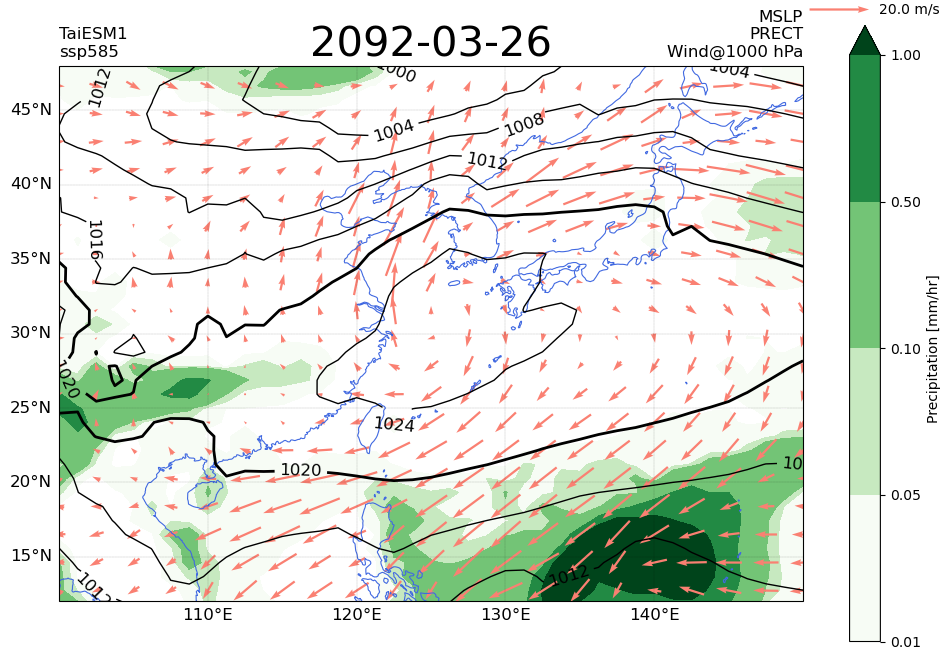

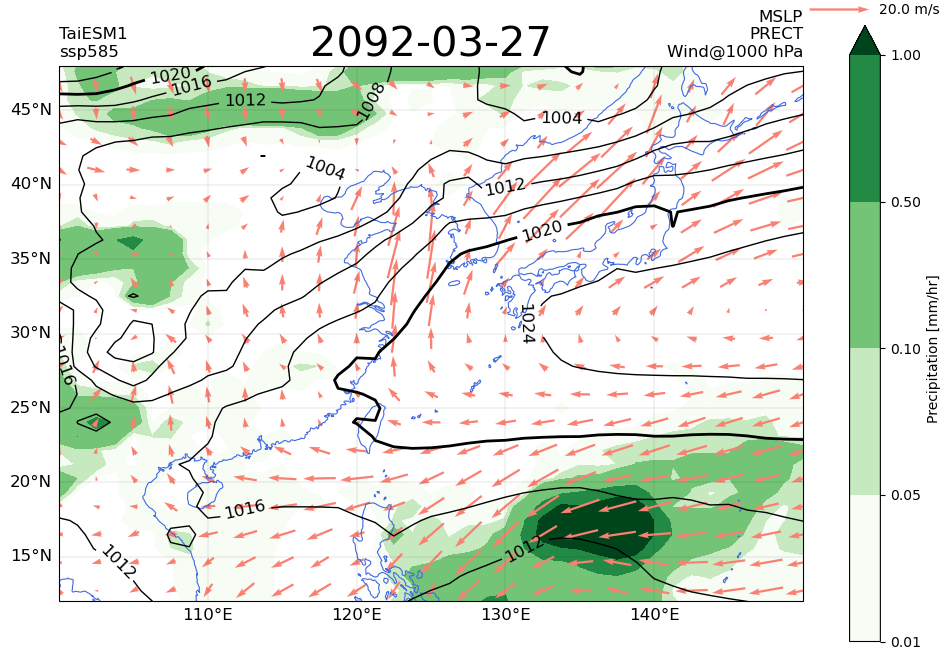

In [4]:
#single plot
[min_lon_plot, max_lon_plot, min_lat_plot, max_lat_plot]=[100.,150.,12.,48.]

slp_levels=np.linspace(980,1040,16)
slp_lws=[2 if (pp-980)%20==0 else 1 for pp in slp_levels]

for dd in ds.time.values:
    dateStr=dd.strftime('%Y-%m-%d')
    print(dateStr)

    ds_plot=ds.sel(time=dateStr).squeeze()
    msl=ds_plot.psl/100
    msl.attrs = ds_plot.psl.attrs
    msl.attrs['units']='hPa'

    prect=ds_plot.pr*1000/998*3600 #mm/hr
    prect.attrs = ds_plot.pr.attrs
    prect.attrs['units']='mm/hr'

    resample = ds_plot.isel(lon=slice(None, None, 2),lat=slice(None, None, 2))
    # Defining the figure
    fig = plt.figure(figsize=(12,8), facecolor='w', edgecolor='k')

    # Axes with Cartopy projection
    ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
    # and extent
    ax.set_extent([min_lon_plot, max_lon_plot, min_lat_plot, max_lat_plot], ccrs.PlateCarree())

    # Plotting using Matplotlib the mean current
    cs_p = prect.plot.contourf(ax=ax,x='lon', y='lat',levels=[0.01,0.05,0.1,0.5,1.0],extend='max',cmap='Greens',transform=ccrs.PlateCarree())
    #cs_p2 = prect.plot.contour(ax=ax,x='lon', y='lat',levels=[0.01,0.05,0.1,0.5,1.0],cmap='hot_r',linewidths=1.2,transform=ccrs.PlateCarree())
    cs = msl.plot.contour(ax=ax,transform=ccrs.PlateCarree(),
                      levels=slp_levels,
                      colors='k',
                      linewidths=slp_lws)
    q1=resample.plot.quiver(ax=ax,x='lon', y='lat', u='ua', v='va', transform=ccrs.PlateCarree(),
                        scale=250,color='salmon',width=0.003,add_guide=False)

    ax.clabel(cs, slp_levels, inline=True, fmt='%.0f', fontsize=12)
    #ax.clabel(cs_p2, [0.01,0.05,0.1,0.5,1.0], inline=True, fmt='%.2f', fontsize=12)
    #q1=ds_plot.plot.quiver(x='lon', y='lat', u='ua', v='va', transform=ccrs.PlateCarree(), scale=80,color='g')
    ax.coastlines(resolution='50m',linewidth=0.8,color='royalblue')
    # Plot lat/lon grid 
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=0.1, color='k', alpha=1, 
                  linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 12}
    gl.ylabel_style = {'size': 12} 

    #ax.plot([min_lon_tw, max_lon_tw,max_lon_tw,min_lon_tw,min_lon_tw],\
    #    [min_lat_tw,min_lat_tw, max_lat_tw,max_lat_tw,min_lat_tw],\
    #    lw=2.5,color='b',transform=ccrs.PlateCarree())
    #x.plot([min_lon_ish, max_lon_ish,max_lon_ish,min_lon_ish,min_lon_ish],\
    #    [min_lat_ish,min_lat_ish, max_lat_ish,max_lat_ish,min_lat_ish],\
    #   lw=2.5,ls='--',color='r',transform=ccrs.PlateCarree())

    ax.set_title(dateStr,fontsize=30)
    ax.set_title('TaiESM1\n%s'%sce,fontsize=12,loc='left')
    ax.set_title('MSLP\nPRECT\nWind@1000 hPa',fontsize=12,loc='right')
    #ax.text(max_lon_tw+1,max_lat_tw-1.5,'prR=%.1f%%'%(prR*100),color='b',fontsize=15,transform=ccrs.PlateCarree())
    #ax.text(max_lon_tw+1,min_lat_tw+1,'WDCor=%.1f $\degree$'%wdCor,color='r',fontsize=15,transform=ccrs.PlateCarree())
    # Vector options declaration
    veclenght = 20
    maxstr = '%3.1f m/s' % veclenght
    plt.quiverkey(q1,0.8,0.9,veclenght,maxstr,labelpos='E', coordinates='figure').set_zorder(11)
    plt.savefig('../figures/weatherMap/%s.%s_%s.png'%(m,sce,dateStr))
